In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from sklearn.datasets import make_blobs

In [4]:
X,y=make_blobs(n_samples=1000, centers=3, n_features=2)

In [5]:
X

array([[  8.59053446,  -2.54469533],
       [  4.70917759,  -6.33000381],
       [  2.98474776, -10.02320022],
       ...,
       [  9.835258  ,  -0.96250629],
       [  5.17055993,  -7.81213256],
       [  9.81810237,  -0.90344452]], shape=(1000, 2))

In [6]:
y

array([0, 2, 1, 0, 1, 1, 0, 2, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 1, 1, 0, 2,
       0, 0, 1, 1, 2, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 2, 2, 1, 1,
       1, 0, 0, 0, 0, 2, 2, 1, 2, 2, 1, 0, 1, 1, 0, 0, 2, 0, 0, 0, 1, 1,
       1, 0, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 2, 2, 1, 1, 1,
       2, 2, 2, 2, 0, 2, 2, 1, 2, 0, 1, 2, 1, 2, 0, 0, 0, 2, 0, 0, 2, 0,
       2, 1, 0, 2, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 1, 0, 2, 1, 2, 0, 2, 2,
       1, 1, 0, 0, 0, 2, 0, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 2, 2, 1, 0, 2,
       2, 0, 2, 0, 1, 0, 2, 2, 1, 2, 0, 1, 1, 2, 0, 1, 1, 1, 0, 2, 2, 0,
       0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 2, 2, 1, 2, 1, 1, 0, 0, 2, 2, 2, 2,
       1, 0, 0, 1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 2, 2, 2, 1, 2, 1, 1, 0, 1, 0, 1, 0, 2, 1, 2, 0, 0, 0, 2, 0, 1,
       0, 0, 2, 0, 0, 0, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 1,
       0, 2, 2, 0, 0, 1, 0, 0, 2, 1, 1, 0, 1, 1, 2, 2, 2, 0, 0, 0, 2, 2,
       1, 0, 1, 1, 0, 2, 1, 0, 2, 1, 1, 1, 2, 2, 1,

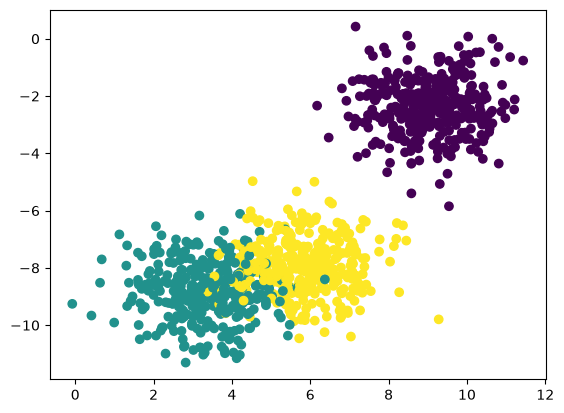

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
# Standardization --features scaling teching
from sklearn.preprocessing import StandardScaler

In [11]:
scaled=StandardScaler()

In [12]:
# Train , Split and test datasets
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test, y_train, y_test=train_test_split(X,y, test_size=0.33, random_state=42)

In [14]:
X_train_scaled=scaled.fit_transform(X_train)
X_test_scaled=scaled.transform(X_test)

In [15]:
from sklearn.cluster import KMeans

In [16]:
# Elbow method to select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [17]:
wcss

[1340.000000000001,
 292.22274644949005,
 154.98988022830073,
 131.16524117671804,
 109.91726662740241,
 93.40967231373877,
 83.77832473520081,
 74.5450587672747,
 65.36561950031901,
 59.60026975034472]

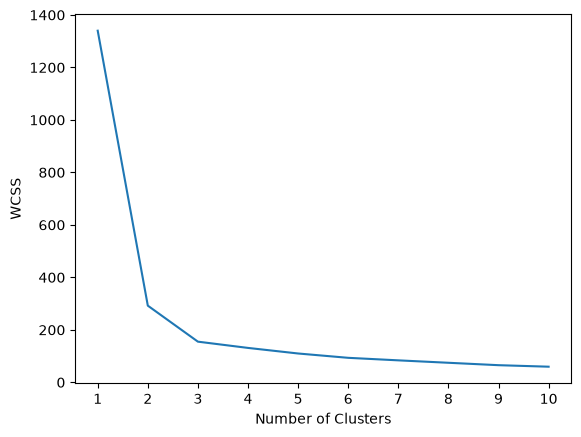

In [18]:
# plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans=KMeans(n_clusters=3, init='k-means++')

In [20]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 1, 2, 1, 0, 2, 2, 1, 0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 2, 1, 2,
       2, 1, 0, 0, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2, 0, 1, 0, 0, 2, 1, 2, 0,
       1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 2, 1, 0, 1, 0, 0, 2,
       1, 2, 0, 1, 2, 1, 0, 1, 1, 2, 1, 2, 2, 1, 1, 1, 0, 1, 0, 0, 2, 0,
       2, 0, 2, 0, 0, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 1, 0, 2, 2, 1, 2, 2,
       0, 1, 2, 0, 0, 1, 2, 1, 2, 2, 0, 0, 1, 0, 2, 1, 0, 2, 1, 2, 0, 0,
       0, 2, 2, 1, 0, 2, 0, 0, 2, 1, 2, 0, 0, 1, 2, 2, 1, 2, 1, 0, 0, 0,
       0, 2, 2, 1, 0, 2, 0, 2, 0, 2, 0, 1, 1, 2, 2, 2, 0, 1, 0, 0, 2, 2,
       0, 2, 2, 0, 0, 0, 2, 1, 1, 1, 0, 0, 2, 1, 2, 1, 0, 1, 1, 2, 0, 0,
       2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 2, 1, 1, 0,
       1, 1, 0, 2, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0,
       2, 0, 1, 1, 1, 0, 2, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 1, 1, 2, 2, 2,
       1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 2,
       0, 1, 2, 1, 0, 1, 2, 0, 0, 2, 1, 2, 2, 2, 2,

In [21]:
y_pred=kmeans.predict(X_test_scaled)

In [22]:
y_pred

array([2, 2, 0, 2, 0, 2, 1, 2, 1, 1, 2, 1, 0, 0, 0, 2, 0, 1, 0, 1, 0, 2,
       2, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 0, 2, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 2, 2, 0, 1, 0, 2, 1, 0, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 1,
       0, 1, 0, 0, 1, 0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 1, 2, 2, 0, 2,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 1, 1, 1, 1, 2, 1, 1, 0, 0, 1, 2,
       1, 1, 2, 1, 2, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 1, 0,
       0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 1, 0, 2, 1, 0, 2, 1, 2, 2, 2, 0,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0,
       0, 1, 0, 2, 0, 2, 1, 1, 2, 0, 2, 0, 1, 2, 2, 2, 1, 1, 2, 2, 2, 0,
       1, 0, 2, 2, 0, 1, 1, 2, 2, 2, 2, 1, 2, 0, 0, 1, 1, 0, 1, 2, 2, 1,
       2, 0, 2, 0, 2, 2, 1, 1, 0, 2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 2, 2, 1, 0,
       2, 0, 0, 2, 0, 2, 1, 0, 1, 2, 1, 0, 0, 1, 0, 0, 2, 0, 0, 1, 2, 0,
       0, 2, 2, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,

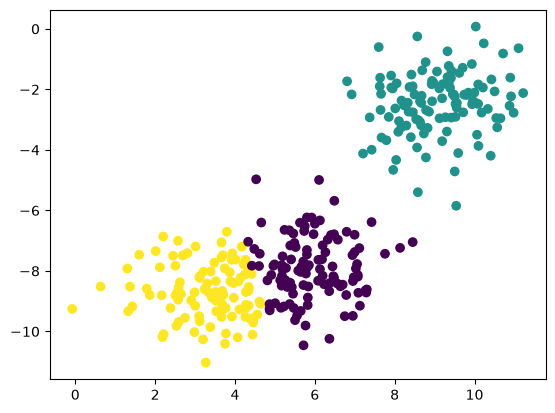

In [23]:
plt.scatter(X_test[:,0],X_test[:,1], c=y_pred)

### Validating the k value
### kneelocator
### Silhoutee scoring

In [26]:
# Kneelocator
!pip install kneed

In [31]:
from kneed import KneeLocator

In [32]:
kl=KneeLocator(range(1,11),wcss,curve='convex', direction='decreasing')

In [33]:
kl.elbow

np.int64(2)

In [34]:
# silhoutte score
from sklearn.metrics import silhouette_score

In [36]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [37]:
silhouette_coefficients

[0.6902468793108738,
 0.5581060756107168,
 0.4676101536543914,
 0.4596417297412116,
 0.3384377092655715,
 0.334659427741741,
 0.3160554445459082,
 0.3381704160066226,
 0.33696656253191853]

Text(0, 0.5, 'Silhoutte Coefficient')

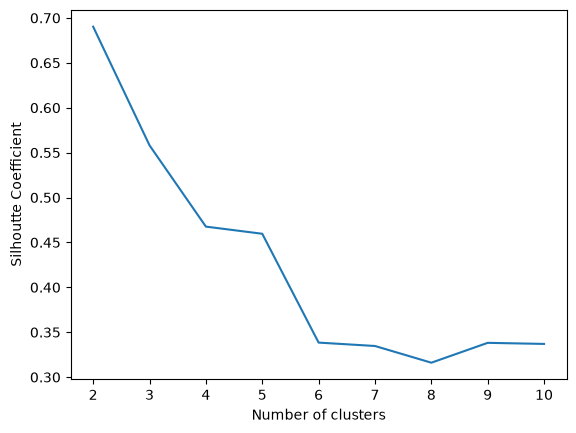

In [38]:
# plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel('Silhoutte Coefficient')